In [1]:
%matplotlib inline
import warnings
# silence the harmless tqdm/ipywidgets notebook warning (cosmetic only)
warnings.filterwarnings("ignore", message="IProgress not found.*")

import numpy as np
import matplotlib.pyplot as plt

from iss_preprocess.io import load_tile_by_coors, get_roi_dimensions

# Relative path to the processed dataset: <project>/<mouse>/<chamber>
data_path = "toksozi_in-vivo-BRISC/BRAC12106.1c/chamber_01"

In [11]:
# --- choose what to load -------------------------------------------------
prefix = "mCherry_NeuN_1_1"
roi = 15
tile_x = 3
tile_y = 4
suffix = "max"
channel = 0

stack = load_tile_by_coors(
    data_path,
    tile_coors=(roi, tile_x, tile_y),
    suffix=suffix,
    prefix=prefix,
)
print(f"loaded {prefix} tile (roi={roi}, x={tile_x}, y={tile_y}) "
      f"-> shape {stack.shape} (X, Y, channels), dtype {stack.dtype}")

loaded mCherry_NeuN_1_1 tile (roi=15, x=3, y=4) -> shape (2460, 3290, 4) (X, Y, channels), dtype uint16


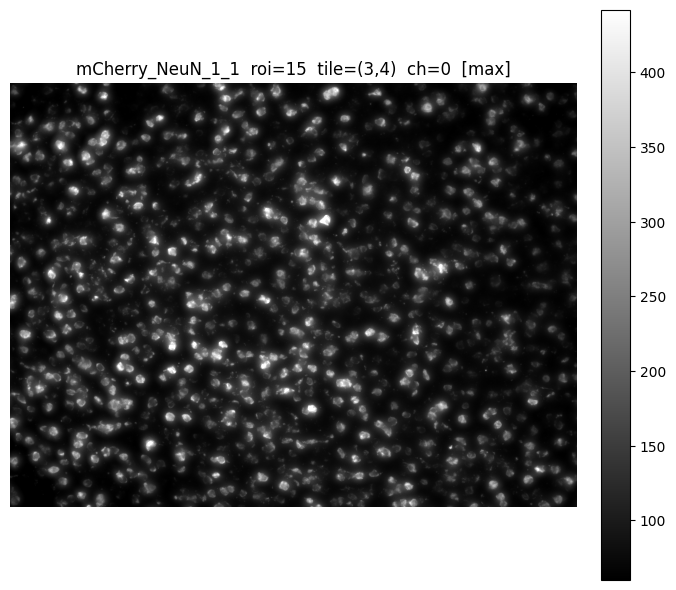

In [12]:
img = stack[:, :, channel]

# robust contrast: signal is sparse on a dark background, so clip to percentiles
vmin, vmax = np.percentile(img, [1, 99.9])

plt.figure(figsize=(8, 8))
plt.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title(f"{prefix}  roi={roi}  tile=({tile_x},{tile_y})  ch={channel}  [{suffix}]")
plt.colorbar(fraction=0.046, pad=0.04)
plt.axis("off")
plt.show()

## Reference-tile registration demo

Walk through the step the pipeline runs first (`run_register_reference_tile`):
load one tile across **all rounds** and estimate the channel/round transforms.
If a round has no structure the shifts come back as `NaN` and the real pipeline
raises `"Reference tforms contain NaNs"`.

Below we run this **non-destructively** (nothing written to disk) for two
candidate `ref_tile`s, `[15, 3, 5]` and `[15, 3, 2]`, to compare them.

In [13]:
# registration imports + parameters (read straight from this dataset's ops)
from iss_preprocess.io import load_ops, load_sequencing_rounds
from iss_preprocess.reg.rounds_and_channels import register_channels_and_rounds

ops = load_ops(data_path)
ref_ch = ops["ref_ch"]
ref_round = ops["ref_round"]
print(f"align_method={ops['align_method']}  ref_ch={ref_ch}  ref_round={ref_round}")
print(f"rounds_min_shift={ops['rounds_min_shift']}  rounds_max_shift={ops['rounds_max_shift']}")


def load_ref_stack(tile, prefix="barcode_round"):
    """Load a tile across every round of a modality -> (X, Y, channels, rounds)."""
    fam = prefix.split("_")[0]                 # "genes" or "barcode"
    nrounds = ops[prefix + "s"]                # ops["genes_rounds"] / ops["barcode_rounds"]
    projection = ops.get(f"{fam}_projection", "max")
    stack = load_sequencing_rounds(
        data_path, tile_coors=tuple(tile), prefix=prefix,
        suffix=projection, nrounds=nrounds,
    )
    return stack, nrounds, projection

align_method=affine  ref_ch=0  ref_round=1
rounds_min_shift=2  rounds_max_shift=250


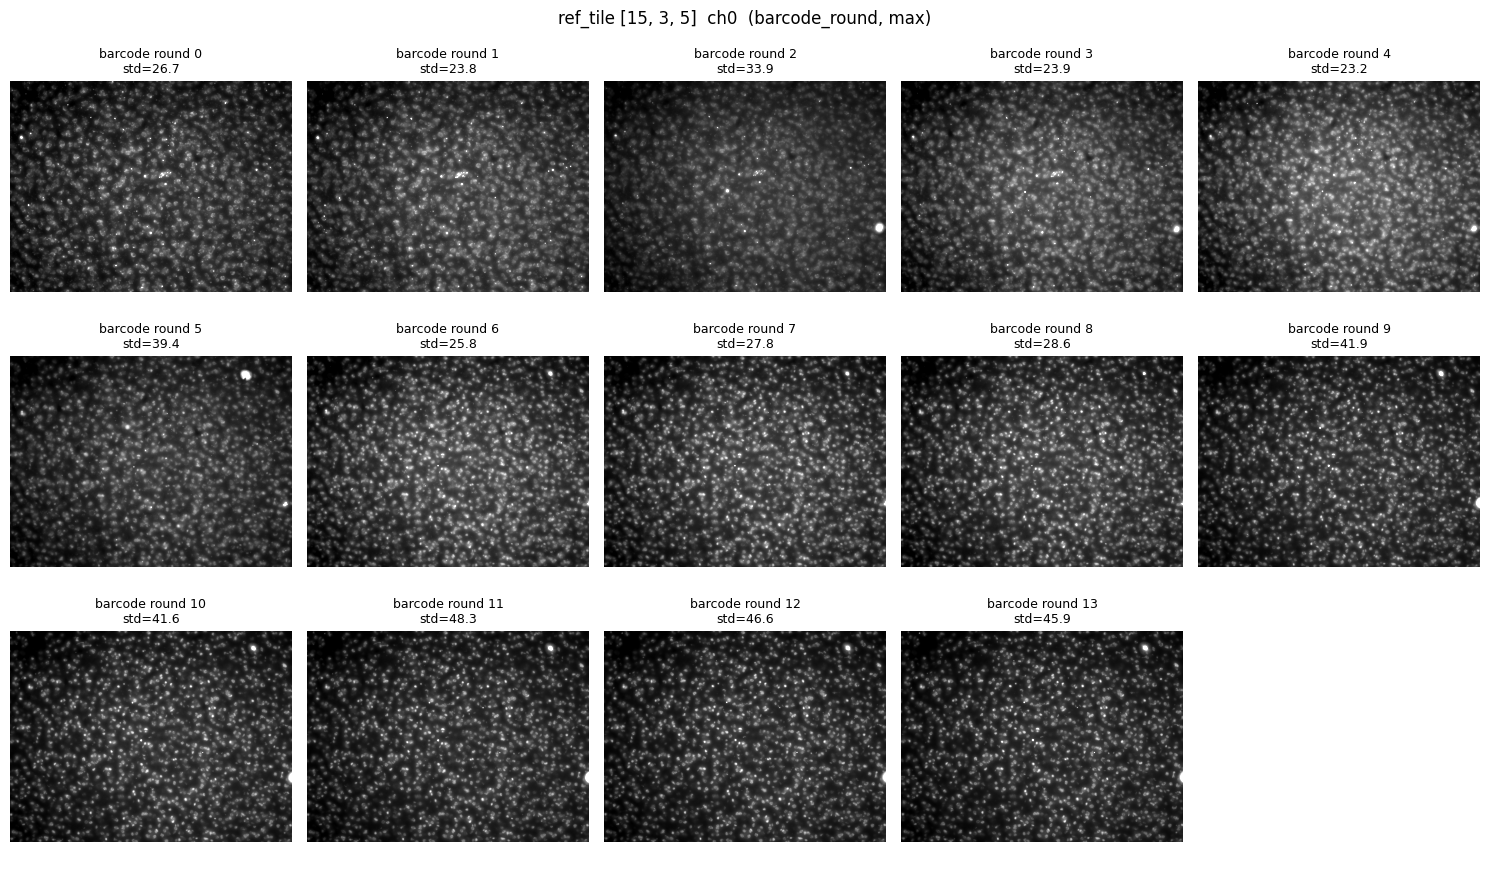

In [14]:
# STEP 1 — look at the reference channel of the tile across every round.
# This is the data the cross-round registration actually works with: a round
# that looks blank here is the one that will produce NaN shifts.
def show_rounds(tile, prefix="barcode_round"):
    stack, nrounds, proj = load_ref_stack(tile, prefix)
    ncol = 5
    nrow = int(np.ceil(nrounds / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3 * ncol, 3 * nrow))
    for r, ax in enumerate(axes.ravel()):
        if r < nrounds:
            img = stack[:, :, ref_ch, r]
            vmin, vmax = np.percentile(img, [1, 99.9])
            ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)
            ax.set_title(f"{prefix.split('_')[0]} round {r}\nstd={img.std():.1f}", fontsize=9)
        ax.axis("off")
    fig.suptitle(f"ref_tile {tile}  ch{ref_ch}  ({prefix}, {proj})")
    plt.tight_layout()
    plt.show()


show_rounds([15, 3, 5], "barcode_round")

In [ ]:
# STEP 2 — run the actual reference-tile registration (same call as the pipeline's
# run_register_reference_tile, but without saving). Reports the per-round shifts of
# the reference channel and whether any transform is NaN (which would crash the run).
# NOTE: register_channels_and_rounds returns NESTED LISTS indexed [channel][round]
# (not numpy arrays), so we coerce to an array for display.
def _any_nan(x):
    try:
        return bool(np.isnan(np.asarray(x, dtype=float)).any())
    except (TypeError, ValueError):
        return any(_any_nan(e) for e in x)


def run_ref_registration(tile, prefix="barcode_round", verbose=False):
    op = prefix.split("_")[0]
    stack, nrounds, proj = load_ref_stack(tile, prefix)
    print(f"=== {prefix}: ref_tile {tile}  ({nrounds} rounds, proj '{proj}') ===")
    angles, shifts, matrix = register_channels_and_rounds(
        stack,
        ref_ch=ref_ch,
        ref_round=ref_round,
        median_filter=ops["reg_median_filter"],
        min_shift=ops["rounds_min_shift"],
        max_shift=ops["rounds_max_shift"],
        align_method=ops["align_method"],
        use_masked_correlation=ops["use_masked_correlation"],
        reg_block_size=ops.get(f"{op}_reg_block_size", 256),
        reg_block_overlap=ops.get(f"{op}_reg_block_overlap", 0.5),
        correlation_threshold=ops.get(f"{op}_correlation_threshold", None),
        max_residual=ops.get(f"{op}_max_residual", 2),
        verbose=verbose,
    )
    has_nan = _any_nan(shifts) or _any_nan(angles) or _any_nan(matrix)
    shifts_arr = np.asarray(shifts, dtype=float)  # -> (n_channels, n_rounds, 2)
    print(f"  per-round shifts of ch{ref_ch} (round {ref_round} is the reference) [dy, dx]:")
    for r in range(nrounds):
        s = shifts_arr[ref_ch, r]
        flag = "  <-- NaN!" if np.isnan(s).any() else ""
        print(f"    round {r:2d}: [{s[0]:7.2f}, {s[1]:7.2f}]{flag}")
    verdict = "CONTAINS NaN -> would CRASH" if has_nan else "OK -> no NaN, registration succeeds"
    print(f"  >>> {verdict}\n")
    return dict(tile=tile, prefix=prefix, shifts=shifts, angles=angles,
                matrix=matrix, has_nan=has_nan)


_ = run_ref_registration([15, 3, 5], "barcode_round")

In [ ]:
# STEP 3 — compare both candidate ref_tiles on both modalities.
# (genes = 7 rounds, barcode = 14 rounds; barcode is the risky one.)
results = []
for tile in ([15, 3, 5], [15, 3, 2]):
    for prefix in ("genes_round", "barcode_round"):
        results.append(run_ref_registration(tile, prefix))

print("summary:")
for r in results:
    print(f"  {r['prefix']:14s} {r['tile']}  ->  {'NaN/CRASH' if r['has_nan'] else 'OK'}")

## Why round-to-round registration works despite blinking rolonies

Overlay one channel of two barcode rounds for a tile. Persistent structure
(tissue, artefacts) is shared → shows white/grey; blinking rolonies are
round-specific → show as separate colours. Phase correlation locks onto the
shared (white) content.

In [ ]:
# overlay two rounds of one channel, BEFORE vs AFTER applying the measured shift.
# Uses np, plt, load_tile_by_coors from the first cell.
from scipy.ndimage import shift as ndi_shift
from skimage.registration import phase_cross_correlation

ov_data_path = "toksozi_in-vivo-BRISC/BRAC12106.1c/chamber_02"
ov_tile = (39, 8, 5)                               # a ref_tile
ov_channel = 0
round_a, round_b = "barcode_round_1_1", "barcode_round_5_1"

a = load_tile_by_coors(ov_data_path, tile_coors=ov_tile, suffix="max", prefix=round_a)[:, :, ov_channel].astype(float)
b = load_tile_by_coors(ov_data_path, tile_coors=ov_tile, suffix="max", prefix=round_b)[:, :, ov_channel].astype(float)

def _norm(x):
    lo, hi = np.percentile(x, [1, 99.8])
    return np.clip((x - lo) / (hi - lo + 1e-9), 0, 1)

an, bn = _norm(a), _norm(b)

# The calculated registration metric: the (dy, dx) shift that aligns round B onto round A
# (the same phase correlation the pipeline uses). Then apply it to round B.
shift_dydx, phase_err, _ = phase_cross_correlation(an, bn, upsample_factor=10)
bn_reg = ndi_shift(bn, shift_dydx, order=1)
print(f"measured shift (dy, dx) {round_b} -> {round_a}, ch{ov_channel}: {np.round(shift_dydx, 2)}")
print(f"pearson r ch{ov_channel}:  raw {np.corrcoef(an.ravel(), bn.ravel())[0, 1]:.3f}"
      f"  ->  registered {np.corrcoef(an.ravel(), bn_reg.ravel())[0, 1]:.3f}")

def _rgb(green):                       # magenta = round A, green = the given round-B image
    o = np.zeros((*an.shape, 3)); o[..., 0] = an; o[..., 1] = green; o[..., 2] = an
    return o

cy, cx = an.shape[0] // 2, an.shape[1] // 2
w = 300
sl = (slice(cy - w, cy + w), slice(cx - w, cx + w))

fig, ax = plt.subplots(2, 2, figsize=(12, 9))
ax[0, 0].imshow(_rgb(bn)[sl]);     ax[0, 0].set_title("RAW (zoom) — magenta=A, green=B\noffset visible on shared structure")
ax[0, 1].imshow(_rgb(bn_reg)[sl]); ax[0, 1].set_title(f"REGISTERED (zoom) — B shifted by {np.round(shift_dydx, 1)}\nshared structure now white")
ax[1, 0].imshow(_rgb(bn));         ax[1, 0].set_title("RAW (full)")
ax[1, 1].imshow(_rgb(bn_reg));     ax[1, 1].set_title("REGISTERED (full)")
for a_ in ax.ravel():
    a_.axis("off")
fig.suptitle(f"{ov_tile} ch{ov_channel}: before vs after the measured shift {np.round(shift_dydx, 2)}\n"
             f"(shared scaffold snaps to white; blinking rolonies stay coloured — they genuinely differ)")
fig.tight_layout()
plt.show()

## Per-tile rolony diagnostic — real barcodes or artefact?

Run on a tile you're unsure about (loads all rounds×channels, ~1 min/tile — not for bulk).
Counts puncta that pass 3 criteria: **(1) spot-sized**, **(2) single-channel per round**
(purity, bleedthrough-tolerant), **(3) dominant channel rotates across rounds**. A real
barcode tile → high `n_rolony`, low `blob_px`; an artefact/dirt tile → low `n_rolony`,
high `blob_px`. Validated: `[36,1,4]` (barcodes) = 173 / 1973 vs `[39,8,5]` (dirt) = 23 / 26282.

In [ ]:
# per-tile rolony diagnostic (loads all rounds x channels, ~1 min/tile)
from scipy.ndimage import shift as ndi_shift, label, find_objects, center_of_mass, gaussian_filter
from skimage.registration import phase_cross_correlation
from iss_preprocess.io import load_ops, load_sequencing_rounds
try:
    from iss_preprocess.image import filter_stack
    _HAVE_FS = True
except Exception:
    _HAVE_FS = False


def _bandpass(stack4d):
    if _HAVE_FS:
        return np.clip(filter_stack(stack4d, r1=2, r2=4), 0, None)
    out = np.zeros_like(stack4d, dtype=float)
    for c in range(stack4d.shape[2]):
        for r in range(stack4d.shape[3]):
            im = stack4d[:, :, c, r].astype(float)
            out[:, :, c, r] = np.clip(gaussian_filter(im, 1) - gaussian_filter(im, 4), 0, None)
    return out


def assess_tile_rolonies(tile, prefix="barcode_round",
                         data_path="toksozi_in-vivo-BRISC/BRAC12106.1c/chamber_02",
                         spot_q=0.999, purity_thr=0.55, min_rounds=3,
                         min_channels=2, size_min=2, size_max=40, blob=150):
    """Score a tile for REAL barcode rolonies: spot-sized + single-channel/round + rotating.

    Returns metrics (n_rolony, n_blob, blob_px, mean_purity_bright) plus arrays to plot.
    """
    nr = load_ops(data_path)[prefix + "s"]
    st = load_sequencing_rounds(data_path, tuple(tile), suffix="max", prefix=prefix, nrounds=nr).astype(float)
    nch = st.shape[2]
    ref = st[:, :, :, 0].max(axis=2)
    for r in range(1, nr):                        # coarse-register rounds so pixels line up
        sh, _, _ = phase_cross_correlation(ref, st[:, :, :, r].max(axis=2), upsample_factor=1)
        for c in range(nch):
            st[:, :, c, r] = ndi_shift(st[:, :, c, r], sh, order=1)
    f = _bandpass(st)                              # spot-scale band-pass (kills blobs/diffuse)
    total = f.sum(axis=2) + 1e-6
    maxv = f.max(axis=2)                           # (X,Y,round)
    argc = f.argmax(axis=2)                        # dominant channel per pixel/round
    purity = maxv / total                          # dominant-channel fraction
    thr = np.quantile(maxv.reshape(-1, nr), spot_q, axis=0)
    spot = (maxv > thr[None, None, :]) & (purity > purity_thr)   # bright, single-channel puncta
    lbl, n = label(spot.any(axis=2))
    sizes = np.bincount(lbl.ravel())
    slices = find_objects(lbl)
    rolony_yx, blob_yx, rot_rows, blob_px = [], [], [], 0
    for comp in range(1, n + 1):
        area = int(sizes[comp]); sl = slices[comp - 1]
        if sl is None:
            continue
        if area > blob:                            # big blob = artefact
            blob_px += area; blob_yx.append(center_of_mass(lbl == comp)); continue
        if not (size_min <= area <= size_max):     # spot-sized only
            continue
        sub = lbl[sl] == comp
        sub_spot, sub_argc = spot[sl], argc[sl]
        chans, row = set(), np.full(nr, -1)
        for r in range(nr):
            m = sub & sub_spot[:, :, r]
            if m.any():
                dom = int(np.bincount(sub_argc[:, :, r][m], minlength=nch).argmax())
                chans.add(dom); row[r] = dom
        if (row >= 0).sum() >= min_rounds and len(chans) >= min_channels:   # rotates across rounds
            cy, cx = center_of_mass(sub)
            rolony_yx.append((sl[0].start + cy, sl[1].start + cx)); rot_rows.append(row)
    bright = maxv > thr[None, None, :]
    return dict(
        tile=tuple(tile), prefix=prefix,
        n_rolony=len(rolony_yx), n_blob=len(blob_yx), blob_px=int(blob_px),
        mean_purity_bright=round(float(purity[bright].mean()), 3),
        disp=maxv.max(axis=2),
        rolony_yx=np.array(rolony_yx) if rolony_yx else np.empty((0, 2)),
        blob_yx=np.array(blob_yx) if blob_yx else np.empty((0, 2)),
        rot_rows=np.array(rot_rows) if rot_rows else np.empty((0, nr)),
    )

In [ ]:
# run the diagnostic on a tile you're unsure about, and visualise
import matplotlib.patches as mpatches
from matplotlib import cm

res = assess_tile_rolonies((39, 8, 5))   # <-- change to any suspect tile, e.g. (36, 1, 4)
print({k: res[k] for k in ("tile", "n_rolony", "n_blob", "blob_px", "mean_purity_bright")})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
d = res["disp"]
ax[0].imshow(d, cmap="magma", vmax=np.percentile(d, 99.9))
if len(res["rolony_yx"]):
    ax[0].scatter(res["rolony_yx"][:, 1], res["rolony_yx"][:, 0], s=14,
                  facecolors="none", edgecolors="lime", linewidths=0.6,
                  label=f"rolony ({res['n_rolony']})")
if len(res["blob_yx"]):
    ax[0].scatter(res["blob_yx"][:, 1], res["blob_yx"][:, 0], s=60, marker="x",
                  c="red", label=f"blob ({res['n_blob']})")
ax[0].legend(loc="upper right")
ax[0].axis("off")
ax[0].set_title(f"{res['tile']}  n_rolony={res['n_rolony']}  blob_px={res['blob_px']}  "
                f"purity={res['mean_purity_bright']}")

rr = res["rot_rows"][:40]   # up to 40 example rolonies: rows=rolonies, cols=rounds, colour=dominant channel
if len(rr):
    ax[1].imshow(np.ma.masked_less(rr, 0), cmap="tab10", vmin=0, vmax=9,
                 aspect="auto", interpolation="none")
    ax[1].set_xlabel("round")
    ax[1].set_ylabel("example rolony")
    ax[1].set_title("dominant channel per round\n(colour changing across a row = rotation = real barcode)")
    ax[1].legend(handles=[mpatches.Patch(color=cm.tab10(c), label=f"ch{c}") for c in range(4)],
                 loc="upper right", fontsize=8)
else:
    ax[1].text(0.5, 0.5, "no rolonies detected", ha="center", va="center")
    ax[1].axis("off")
plt.tight_layout()
plt.show()